<a href="https://colab.research.google.com/github/kenzuroid-tech/PVCK_Ganjil_2026/blob/main/Tugas_Praktikum_D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import matplotlib.pyplot as plt
from skimage import data
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io, data
from google.colab.patches import cv2_imshow

Ukuran pixel image: (400, 600, 3)


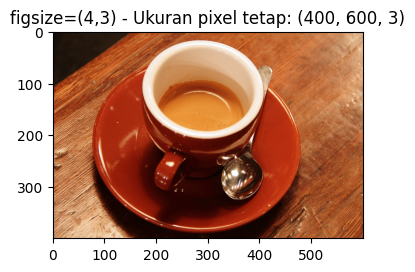

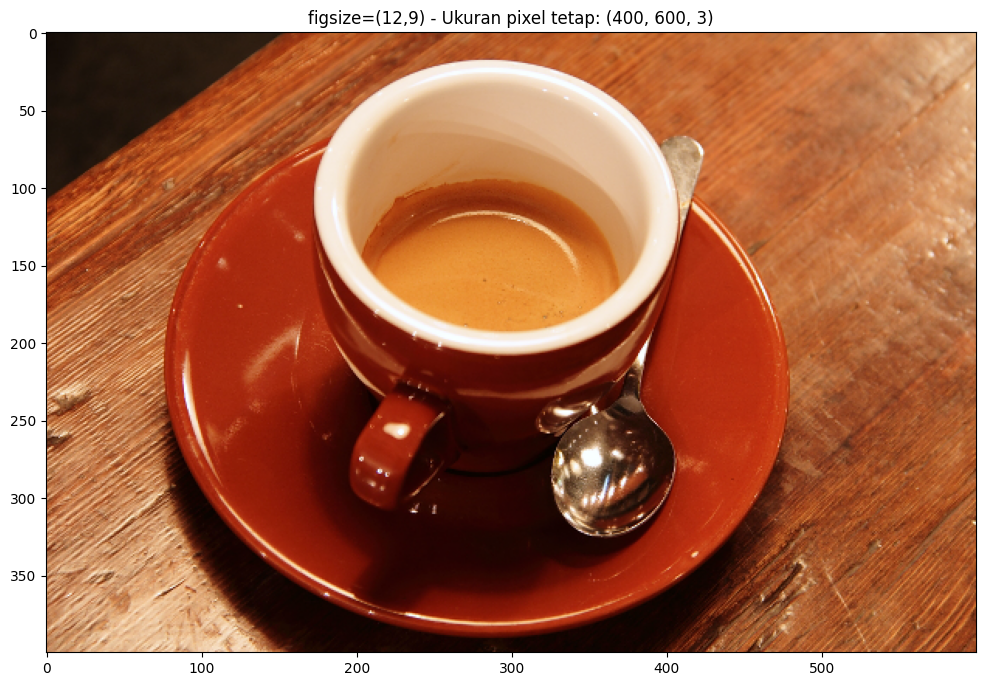

In [16]:
img_d3 = data.coffee()
print(f'Ukuran pixel image: {img_d3.shape}')

# Tampilkan dengan figsize kecil
plt.figure(figsize=(4, 3))
plt.imshow(img_d3)
plt.title(f'figsize=(4,3) - Ukuran pixel tetap: {img_d3.shape}')
plt.show()

# Tampilkan dengan figsize besar
plt.figure(figsize=(12, 9))
plt.imshow(img_d3)
plt.title(f'figsize=(12,9) - Ukuran pixel tetap: {img_d3.shape}')
plt.show()

print(f'\nKesimpulan: figsize HANYA mengubah ukuran tampilan di layar (display size),')
print(f'TIDAK mengubah ukuran pixel image. Pixel tetap {img_d3.shape}')

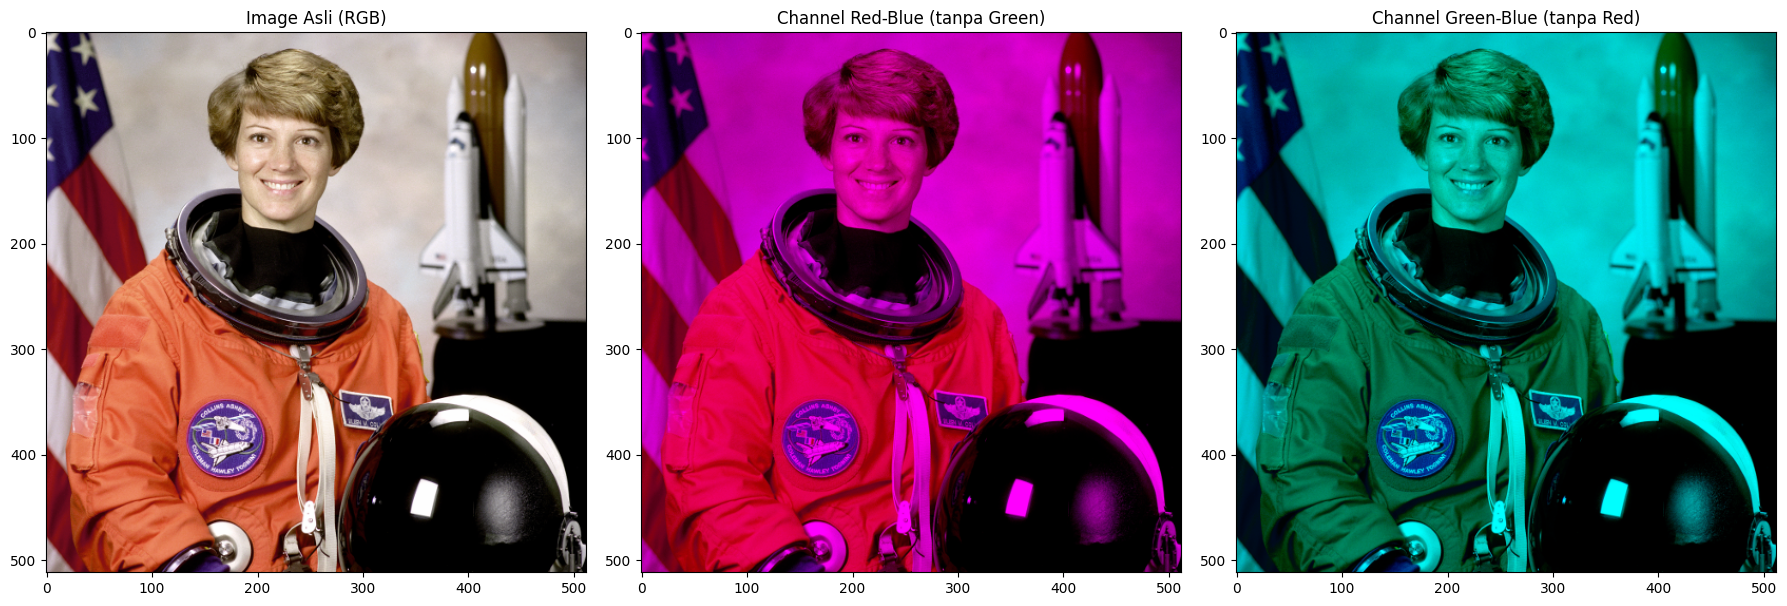

In [4]:
img_rgb = data.astronaut()

# Channel Red-Blue saja (Green = 0)
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0  # Hapus channel Green

# Channel Green-Blue saja (Red = 0)
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0  # Hapus channel Red

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('Image Asli (RGB)')
axes[1].imshow(img_rb)
axes[1].set_title('Channel Red-Blue (tanpa Green)')
axes[2].imshow(img_gb)
axes[2].set_title('Channel Green-Blue (tanpa Red)')
plt.tight_layout()
plt.show()

Ukuran image hasil crop: (96, 96, 3)


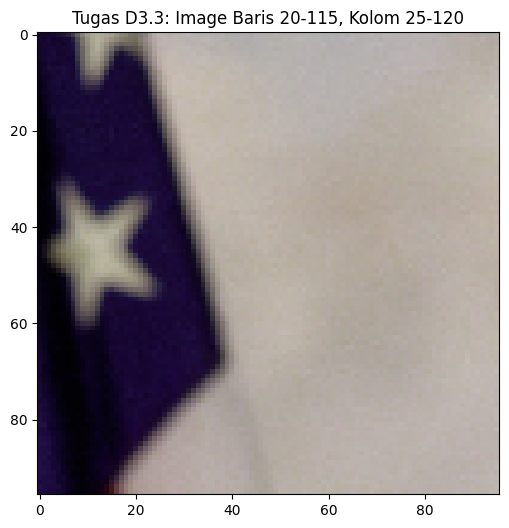

In [5]:
# Tugas D3.3: Tampilkan image baris ke 20-115, kolom 25-120
img_crop = img_rgb[20:116, 25:121]  # slicing baris 20-115, kolom 25-120
print(f'Ukuran image hasil crop: {img_crop.shape}')

plt.figure(figsize=(6, 6))
plt.imshow(img_crop)
plt.title('Tugas D3.3: Image Baris 20-115, Kolom 25-120')
plt.show()

Ukuran slice: (26, 512)


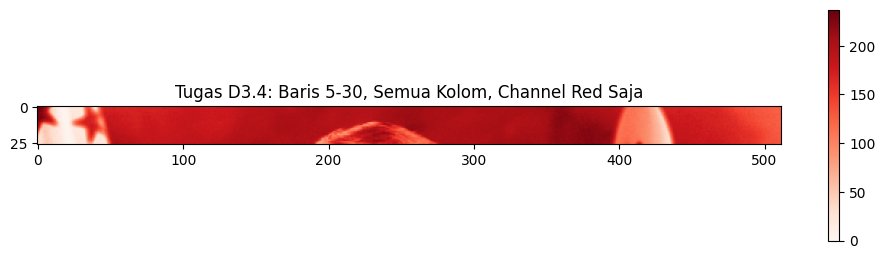

In [6]:
# Tugas D3.4: Tampilkan image baris ke 5-30, semua kolom, channel Red saja
img_red_slice = img_rgb[5:31, :, 0]  # Baris 5-30, semua kolom, channel Red (index 0)
print(f'Ukuran slice: {img_red_slice.shape}')

plt.figure(figsize=(12, 3))
plt.imshow(img_red_slice, cmap='Reds')
plt.title('Tugas D3.4: Baris 5-30, Semua Kolom, Channel Red Saja')
plt.colorbar()
plt.show()

Kotak 1: posisi=(102,270), ukuran=146x111, warna=(238, 70, 152)
Kotak 2: posisi=(121,214), ukuran=114x114, warna=(137, 166, 149)
Kotak 3: posisi=(359,151), ukuran=42x61, warna=(102, 51, 137)
Kotak 4: posisi=(413,191), ukuran=99x60, warna=(210, 253, 107)
Kotak 5: posisi=(21,252), ukuran=147x128, warna=(98, 108, 219)


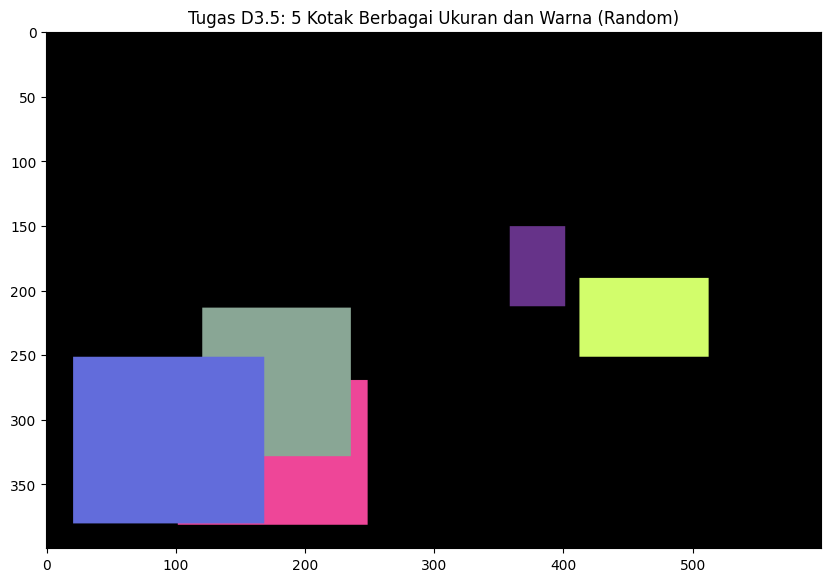

In [9]:
# Tugas D3.5: Buat 5 kotak berbagai ukuran dan warna yang berbeda (random)
img_boxes = np.zeros((400, 600, 3), dtype=np.uint8)

np.random.seed(42)
for i in range(5):
    x1 = np.random.randint(0, 480)
    y1 = np.random.randint(0, 280)
    w_box = np.random.randint(40, 150)
    h_box = np.random.randint(40, 150)
    color = tuple(np.random.randint(50, 256, 3).tolist())
    cv2.rectangle(img_boxes, (x1, y1), (x1 + w_box, y1 + h_box), color, -1)
    print(f'Kotak {i+1}: posisi=({x1},{y1}), ukuran={w_box}x{h_box}, warna={color}')

plt.figure(figsize=(10, 7))
plt.imshow(img_boxes)
plt.title('Tugas D3.5: 5 Kotak Berbagai Ukuran dan Warna (Random)')
plt.show()

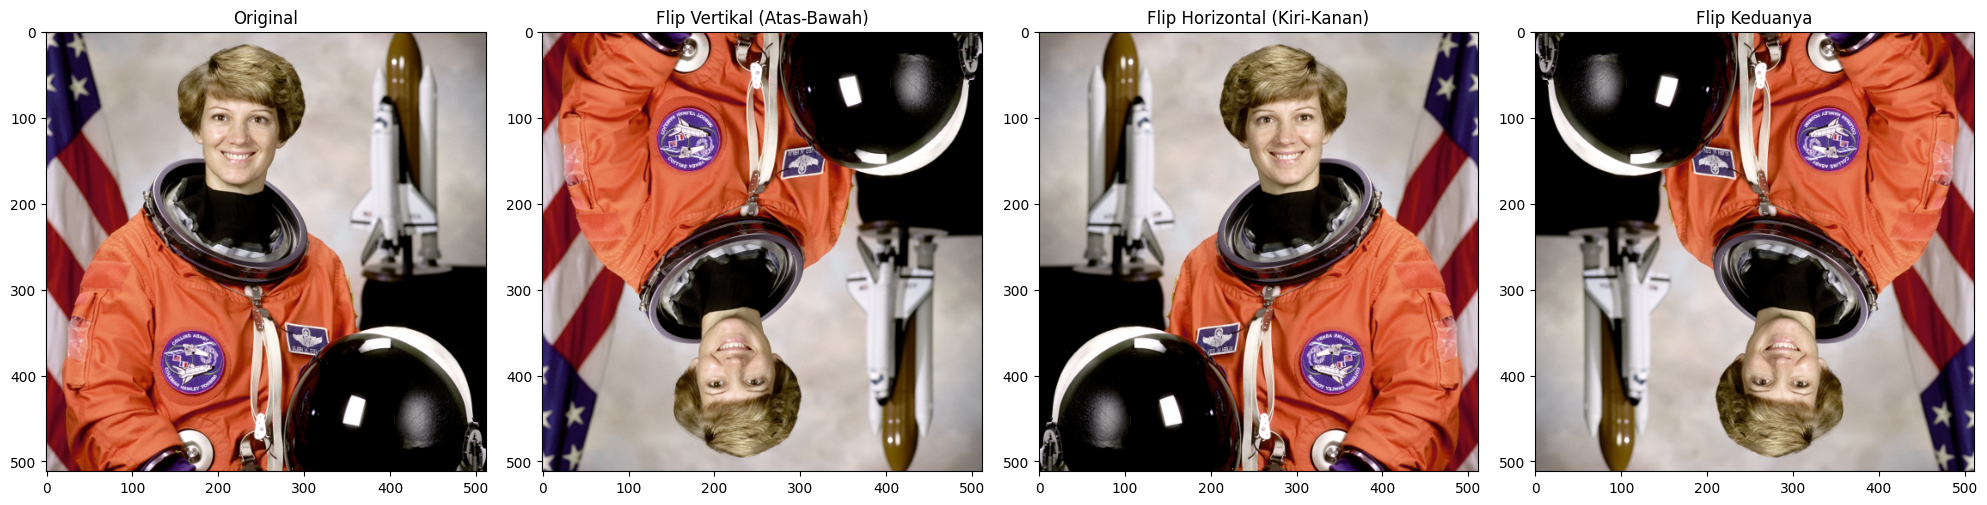

In [10]:
# Tugas D3.6: Tampilkan image dengan posisi terbalik
img_flip_src = data.astronaut()

img_flip_v = cv2.flip(img_flip_src, 0)     # Flip vertikal (atas-bawah)
img_flip_h = cv2.flip(img_flip_src, 1)     # Flip horizontal (kiri-kanan)
img_flip_both = cv2.flip(img_flip_src, -1) # Flip keduanya

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img_flip_src)
axes[0].set_title('Original')
axes[1].imshow(img_flip_v)
axes[1].set_title('Flip Vertikal (Atas-Bawah)')
axes[2].imshow(img_flip_h)
axes[2].set_title('Flip Horizontal (Kiri-Kanan)')
axes[3].imshow(img_flip_both)
axes[3].set_title('Flip Keduanya')
plt.tight_layout()
plt.show()

Saving 10.jpeg to 10 (1).jpeg
Berhasil mendeteksi 1 wajah.


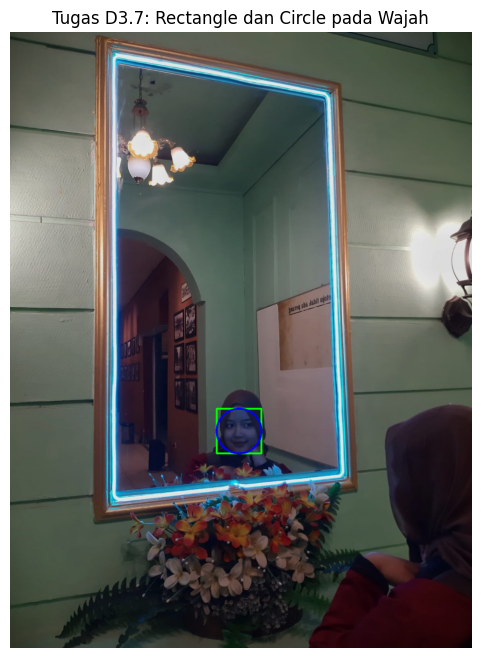

In [13]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = next(iter(uploaded))
img = cv2.imread(filename)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# Deteksi wajah
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

# Gambar rectangle dan circle
img_face = img.copy()

for (x, y, w, h) in faces:

    # Rectangle hijau
    cv2.rectangle(
        img_face,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

    # Titik tengah wajah
    center_x = x + w // 2
    center_y = y + h // 2

    # Radius lingkaran
    radius = max(w, h) // 2

    # Circle merah
    cv2.circle(
        img_face,
        (center_x, center_y),
        radius,
        (255, 0, 0),
        3
    )

print(f"Berhasil mendeteksi {len(faces)} wajah.")

# BGR -> RGB agar warna benar saat ditampilkan matplotlib
img_face_rgb = cv2.cvtColor(img_face, cv2.COLOR_BGR2RGB)

# Tampilkan
plt.figure(figsize=(8, 8))
plt.imshow(img_face_rgb)
plt.title("Tugas D3.7: Rectangle dan Circle pada Wajah")
plt.axis("off")
plt.show()

Ukuran image kitten: (300, 451, 3)


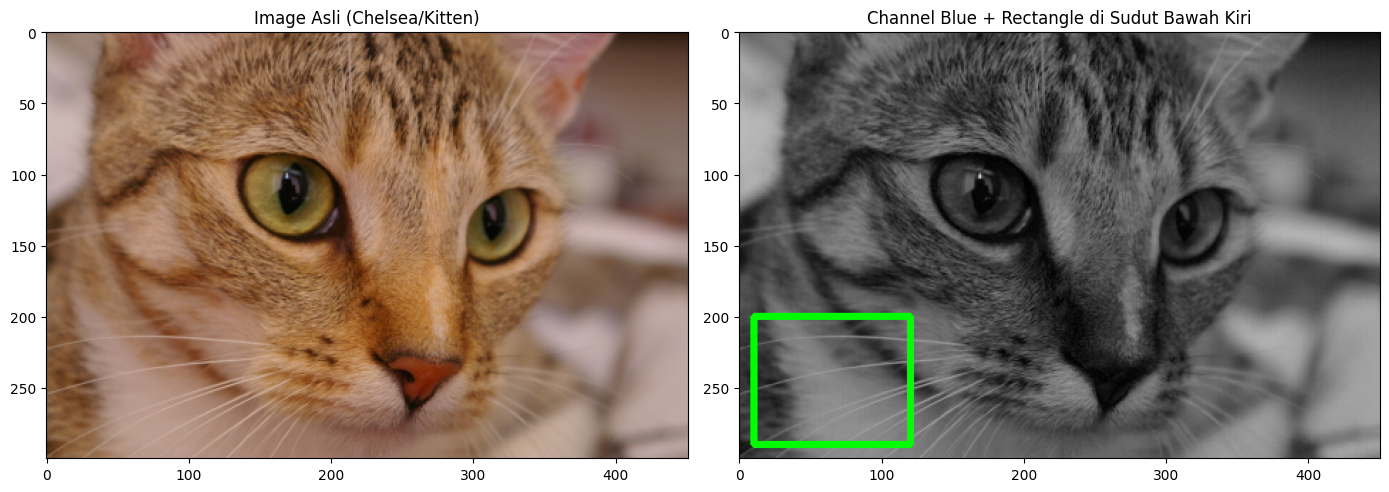

In [14]:
# Tugas D3.8: Rectangle pada sudut bawah kiri channel B dari citra kitten
img_kitten = data.chelsea()  # kitten/cat image dari skimage
print(f'Ukuran image kitten: {img_kitten.shape}')

# Ekstrak channel Blue (index 2 dalam RGB)
blue_channel = img_kitten[:, :, 2]

# Konversi ke 3 channel agar bisa digambar rectangle berwarna
blue_3ch = cv2.cvtColor(blue_channel, cv2.COLOR_GRAY2RGB)

h, w = blue_3ch.shape[:2]

# Gambar rectangle hijau di sudut bawah kiri
cv2.rectangle(blue_3ch, (10, h - 100), (120, h - 10), (0, 255, 0), 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img_kitten)
axes[0].set_title('Image Asli (Chelsea/Kitten)')
axes[1].imshow(blue_3ch)
axes[1].set_title('Channel Blue + Rectangle di Sudut Bawah Kiri')
plt.tight_layout()
plt.show()

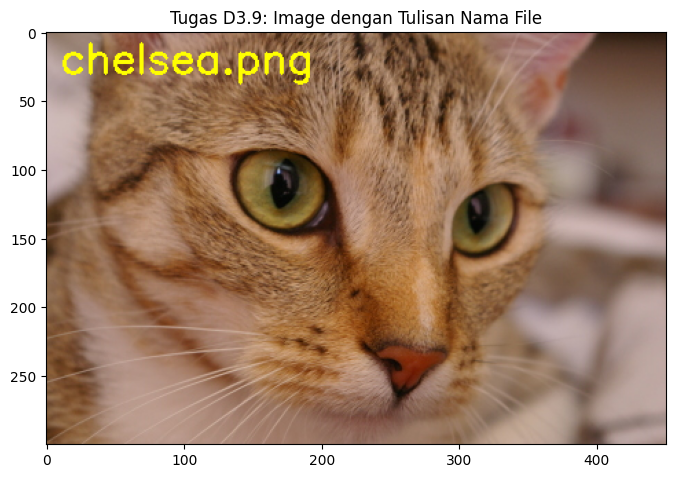

In [15]:
# Tugas D3.9: Lengkapi tulisan nama file pada citra
img_text = data.chelsea().copy()

# Konversi RGB ke BGR untuk OpenCV
img_bgr = cv2.cvtColor(img_text, cv2.COLOR_RGB2BGR)

# Tambahkan text nama file
nama_file = 'chelsea.png'
cv2.putText(img_bgr, nama_file,
            (10, 30),                          # posisi text
            cv2.FONT_HERSHEY_SIMPLEX,          # jenis font
            1,                                  # ukuran font
            (0, 255, 255),                     # warna (cyan dalam BGR)
            2)                                  # ketebalan garis

# Konversi kembali ke RGB untuk matplotlib
img_result = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_result)
plt.title('Tugas D3.9: Image dengan Tulisan Nama File')
plt.show()